# 다항 회귀 이해
* 다항(polynomial) 회귀 : 회귀가 독립 변수의 단항식이 아닌 고차 방정식의 다항식으로 표현되는 것
  * 다항회귀 역시 선형 회귀임에 주의(선형/비선형을 나누는 기준은 회귀계수가 선형/비선형인지의 여부(O) 독립변수의 선형/비선형 여부(X))
  * y = w1x1 + w2x2 + w3x1x2 + w4x1^2 + x5x2^2 -> z=[x1, x2, x1x2, x1^2, x2^2]라 하면 y= w1z1 + w2z2 + w3z3 + w4z4 + w5z5로 선형회귀
* 사이킷런에서 다항 회귀 위한 클래스 명시적 제공 안함 -> 비선형 함수를 선형모델에 적용시키는 방법 사용
  * PolynomialFeatures 클래스로 피처를 다항식 피처로 변환
  * degree 파라미터 : 입력받은 단항식 피처를 degree에 해당하는 다항식 피처로 변환함

In [3]:
from sklearn.preprocessing import PolynomialFeatures
import numpy as np

#다항식으로 변환한 단항식 생성. 2X2 행렬
x = np.arange(4).reshape(2, 2)
print('일차 단항식 계수 피처 : \n', x)

#2차 다항식으로 변환 : [x1, x2] -> [1, x1, x2, x1^2, x1x2, x2^2]
poly = PolynomialFeatures(degree=2)
poly.fit(x)
poly_ftr = poly.transform(x)
print('변환된 2차 다항식 계수 피처 : \n', poly_ftr)

일차 단항식 계수 피처 : 
 [[0 1]
 [2 3]]
변환된 2차 다항식 계수 피처 : 
 [[1. 0. 1. 0. 0. 1.]
 [1. 2. 3. 4. 6. 9.]]


In [4]:
###3차 다항 회귀 함수식 이용해 설정하고 회귀 계수 예측하기

#3차 다항식 회귀의 결정 함수식 위한 함수. 계수 피처 값이 입력되면 결정값을 반환
def polynomial_func(x):
    y = 1 + 2*x[:, 0] + 3*x[:, 0]**2 + 4*x[:, 1]**3
    return y

x = np.arange(4).reshape(2, 2)
print('일차 단항식 계수 feature : \n', x)
y = polynomial_func(x)
print('삼차 다항식 결정값 : \n', y)

일차 단항식 계수 feature : 
 [[0 1]
 [2 3]]
삼차 다항식 결정값 : 
 [  5 125]


In [9]:
from sklearn.linear_model import LinearRegression

# 일차 단항시 계수를 삼차 다항식 계수로 변환
poly_ftr = PolynomialFeatures(degree=3).fit_transform(x)
print('3차 다항식 계수 feature : \n', poly_ftr)

#선형 회귀에 적용
model = LinearRegression()
model.fit(poly_ftr, y)
print('Polynomial 회귀 계수 : \n', np.round(model.coef_, 2))
print('Polynomial 회귀 Shape : ', model.coef_.shape)

3차 다항식 계수 feature : 
 [[ 1.  0.  1.  0.  0.  1.  0.  0.  0.  1.]
 [ 1.  2.  3.  4.  6.  9.  8. 12. 18. 27.]]
Polynomial 회귀 계수 : 
 [0.   0.18 0.18 0.36 0.54 0.72 0.72 1.08 1.62 2.34]
Polynomial 회귀 Shape :  (10,)


* 위 예제에서 일차 단항식 계수 피처 2개 -> 3차 다항식 polynomial 변환 이후에는 다항식 계수 피처가 10개 늘어남
* 이 피처 데이터 세트에 LInearRegression 통해 3차 다항 회귀 형태의 다항 회귀 적용 시 회귀 계수 10개로 늘어남
  * 10개의 회귀 계수 : [0.   0.18 0.18 0.36 0.54 0.72 0.72 1.08 1.62 2.34]
  * 원래 다항식 1 + 2*x1 + 3*x1^2 + 4x2^2의 계수인 [1, 2, 0, 3, 0, 0, 0, 0, 0, 4]와는 차이가 있긴 하나, 다항 회귀로 근사하고 있음
* 즉, PolynomialFeatures로 피처 변한한 후 LinearRegression 클래스로 다항 회귀 구현
* 피처 변환과 선형 회귀 적용 각각 별도로 하는 것보다는 Pipeline 객체 이용해 한 번에 다항 회귀 구현하는 것이 더 명료!

In [1]:
### Pipeline 이용

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
import numpy as np

def polynomial_func(x):
    y = 1 + 2*x[:, 0] + 3*x[:, 0]**2 + 4*x[:, 1]**3
    return y

model = Pipeline([('poly', PolynomialFeatures(degree=3)), ('linear', LinearRegression())])
x = np.arange(4).reshape(2, 2)
y = polynomial_func(x)

model = model.fit(x, y)

print('Polynomial 회귀 계수 : \n', np.round(model.named_steps['linear'].coef_, 2))

Polynomial 회귀 계수 : 
 [0.   0.18 0.18 0.36 0.54 0.72 0.72 1.08 1.62 2.34]


# 다항 회귀를 이용한 과소적합 및 과적합 이해
* 다항 회귀의 차수를 높일 수록 학습 데이터에만 너무 맞춘 과적합 이루어짐 -> 테스트 환경에서 예측 정확도 떨어짐

# 편향-분산 트레이드오프(Bias-Variance Trade off)
* 편향-분산 트레이드오프는 머신러닝의 극복 과제 중 하나임
  * 지나치게 한 방향성으로 치우짐 -> 고편향성(high bias) 가짐
  * 학습 데이터 하나하나의 특성을 반영하며 매우 복잡한 모델, 지나치게 높은 변동성 가짐 -> 고분산(high variance)성 가짐
* 편향과 분산의 고/저에 따른 표현
  * 저편향/저분산 : 예측 결과와 실제 결과가 근접, 예측 변동 크지 않고 특정 부분에 집중 -> 제일 좋은 성능
  * 저편향/고분산 : 예측 결과와 실제 결과가 근접, 예측 결과가 실제 결과를 중심으로 넓게 분포
  * 고편향/저분산 : 정확한 결과에서 벗어나면서도 예측이 특정 부분에 집중
  * 고편향/고분산 : 정확한 예측 결과 벗어나면서도 넓은 부분에 분포
  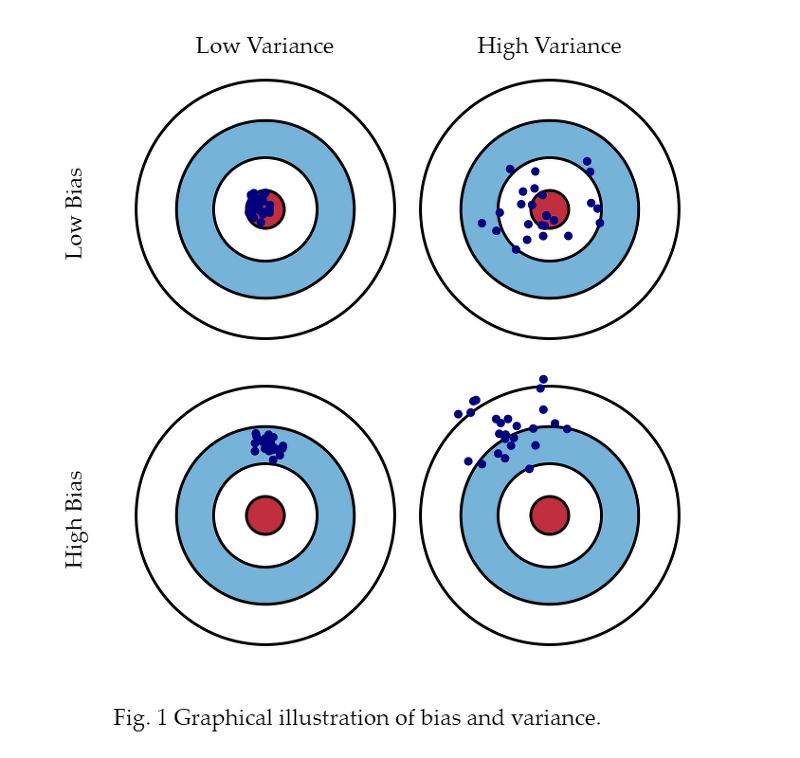
* 일반적으로 편향과 분산은 한 쪽이 높으면 한 쪽이 낮아짐
* '골디락스' 지점에서 비슷
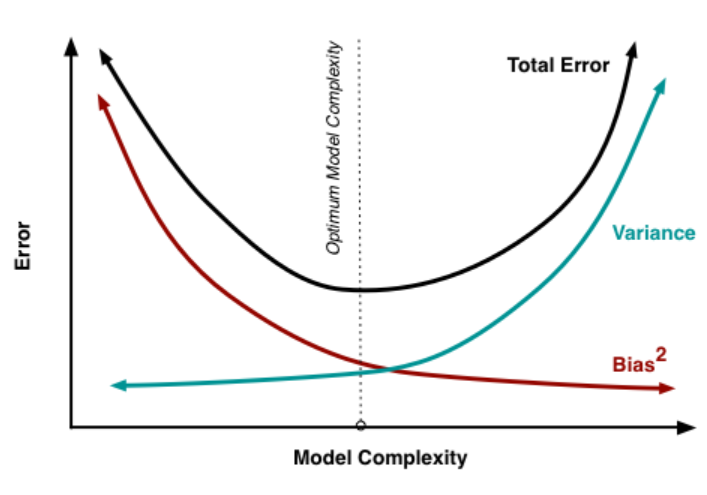
* 고편향, 저분산에서 과소적합 / 저편향, 고분산에서 과적합
* 편향과 분산이 트레이드오프 이루며 오류 cost 값이 최대로 낮아지는 모델 구축하자